Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_excel('premiums_rest.xlsx')
df.shape

(29904, 13)

In [3]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [4]:
df['Genetical_Risk'] = 0

In [5]:
df.columns =df.columns.str.replace(' ', '_').str.lower()

## Checking and fixing Null Values and duplicates

In [6]:
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [7]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## EDA

In [8]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.379910,23.364184,20892.303821,0.0
std,13.412657,1.431201,24.740339,6936.813440,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [9]:
df[df['number_of_dependants'] < 0].shape
df['number_of_dependants'] = abs(df['number_of_dependants'])
df[df['number_of_dependants'] < 0].shape

(0, 14)

In [10]:
numeric_columns = df.select_dtypes(['float64', 'int64']).columns

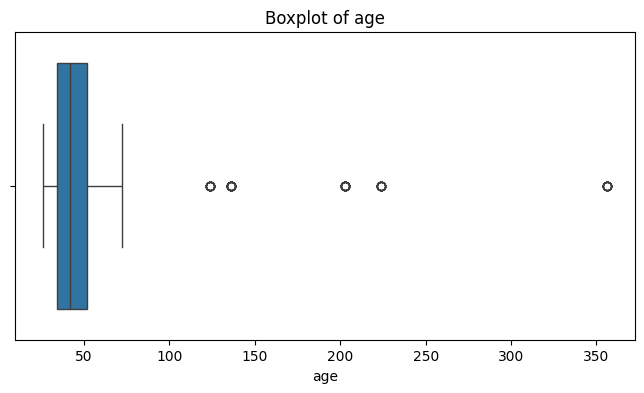

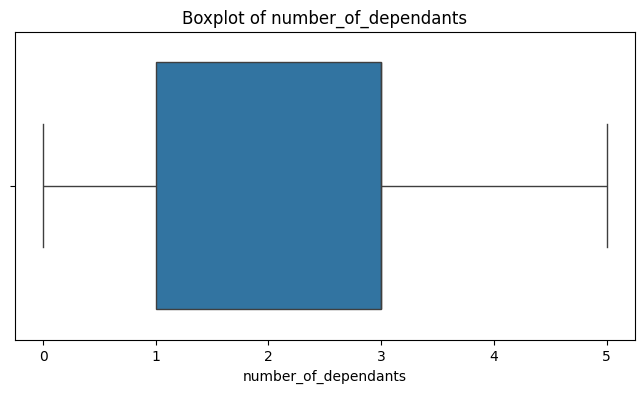

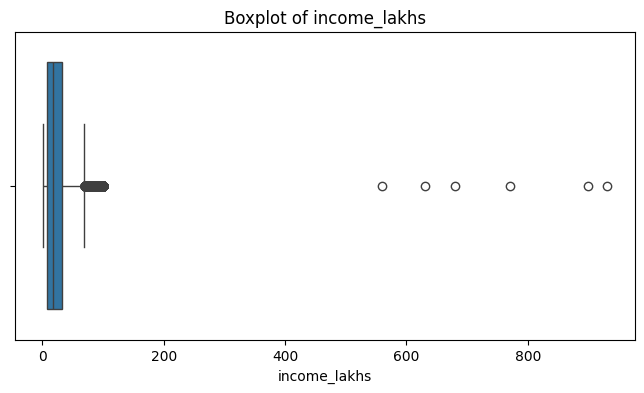

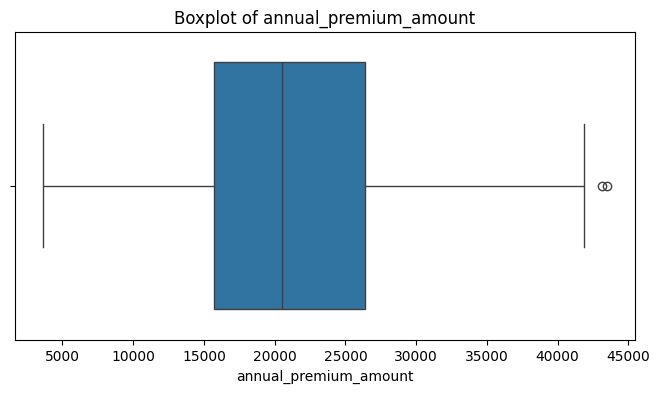

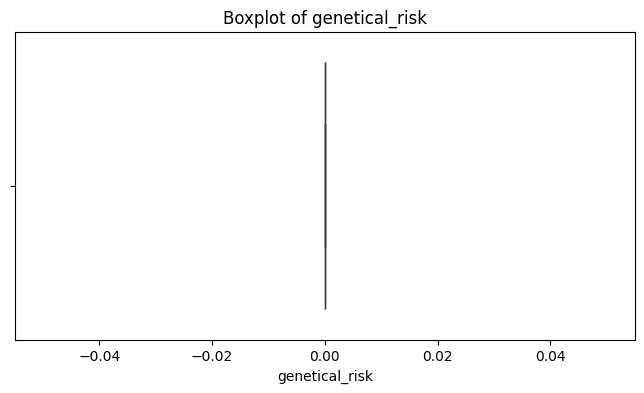

In [11]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [12]:
df[df['age'] > 100].shape
# df1 is after cleaning age column by removing outliers
df1 = df[df['age'] < 100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29828.000000,29828.000000,29828.000000,29828.000000,29828.0
mean,43.095380,2.387790,23.371530,20901.900563,0.0
std,11.041991,1.420641,24.751262,6928.457636,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15706.000000,0.0
50%,42.000000,3.000000,17.000000,20496.000000,0.0
75%,52.000000,3.000000,32.000000,26361.000000,0.0
max,72.000000,5.000000,930.000000,43471.000000,0.0


<Axes: xlabel='income_lakhs', ylabel='Count'>

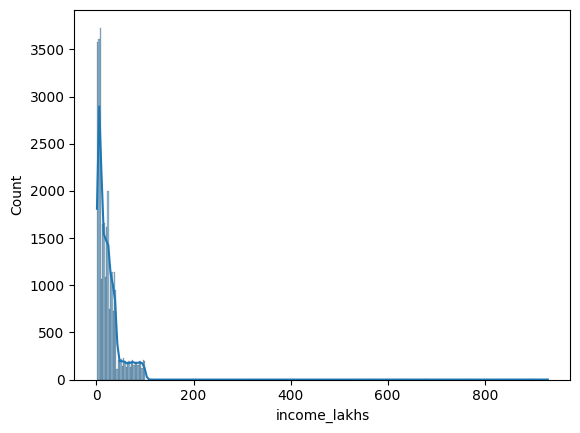

In [13]:
sns.histplot(df1['income_lakhs'], kde=True)

In [14]:
def get_quantile(col):
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [15]:
get_quantile('income_lakhs')

(np.float64(-30.5), np.float64(69.5))

In [16]:
# df2 is after cleaning income_lakhs column by removing outliers
df2 = df1[df1['income_lakhs'] <= df1['income_lakhs'].quantile(0.999)].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.0
mean,43.094896,2.387734,23.226343,20900.689223,0.0
std,11.042430,1.420644,22.455408,6928.192115,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15705.250000,0.0
50%,42.000000,3.000000,17.000000,20495.500000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,72.000000,5.000000,100.000000,43471.000000,0.0


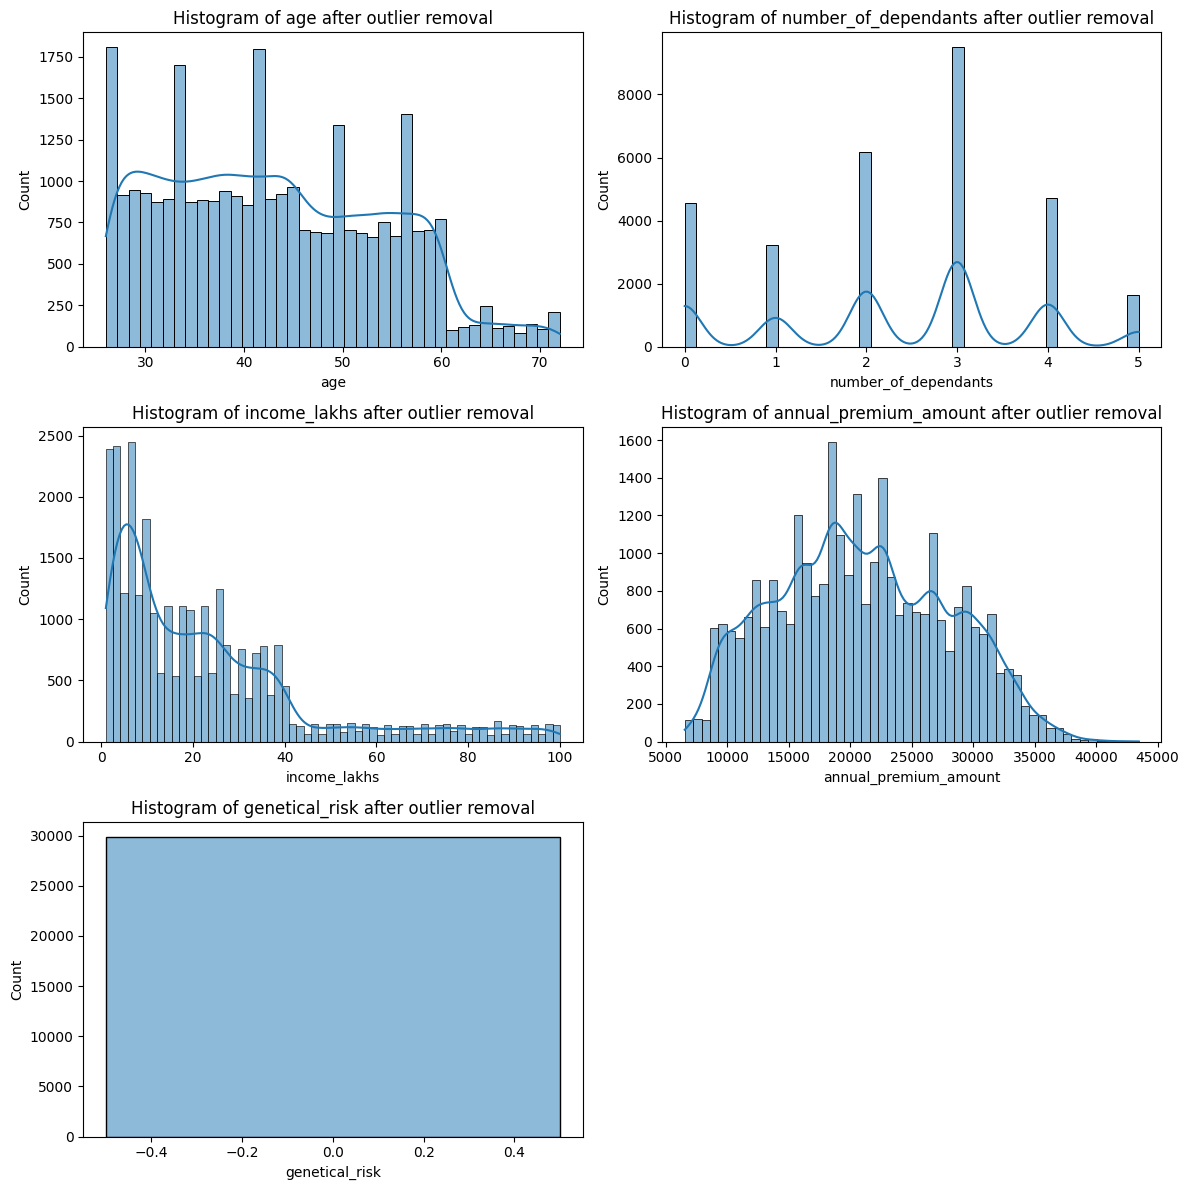

In [17]:
n_cols = 2
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(numeric_columns):
    sns.histplot(df2[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col} after outlier removal')

# Hide extra empty plots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


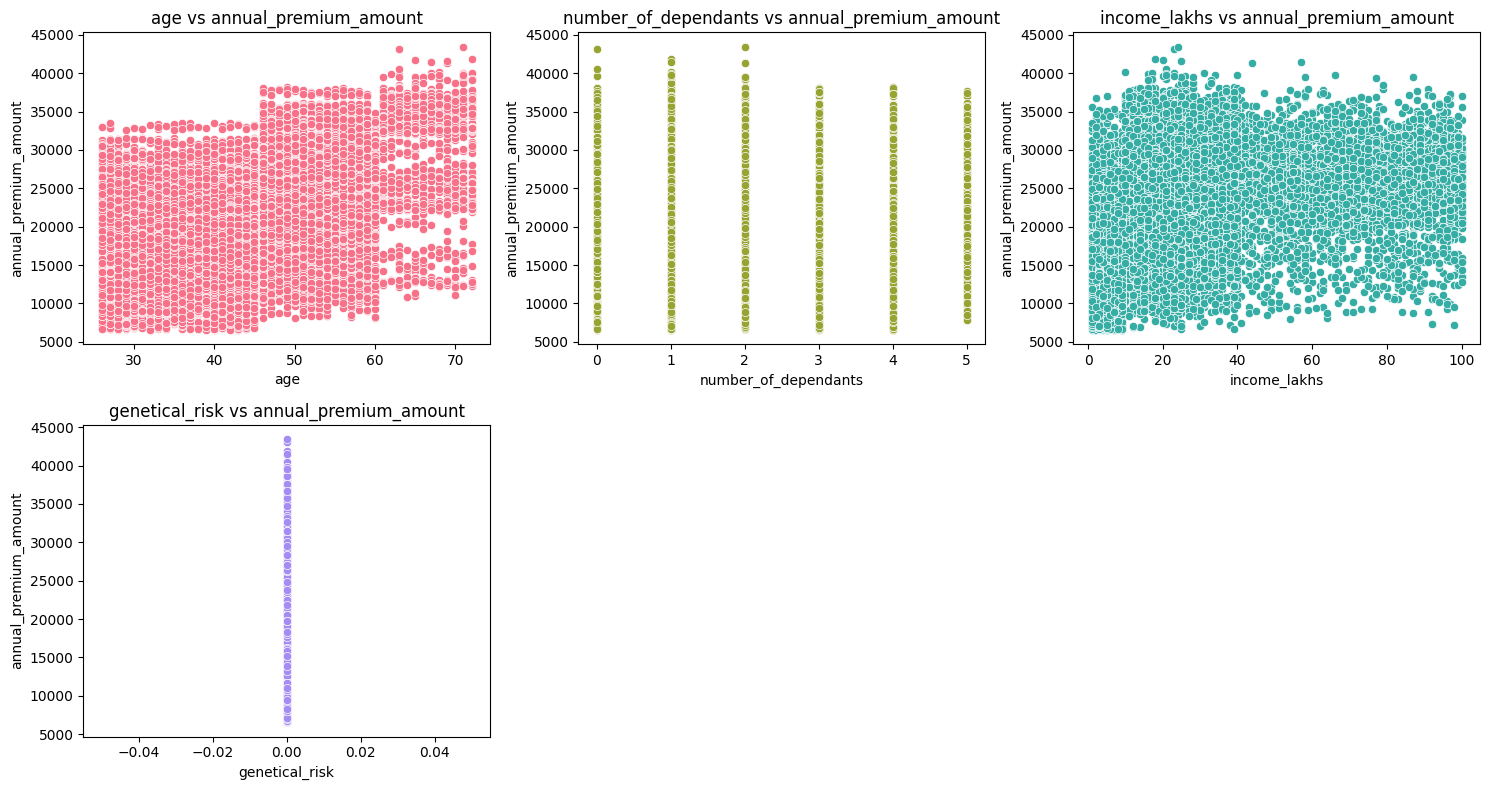

In [18]:
target = 'annual_premium_amount'

# Exclude target column
cols = [col for col in numeric_columns if col != target]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Color palette
colors = sns.color_palette("husl", len(cols))

for i, col in enumerate(cols):
    sns.scatterplot(
        x=df2[col],
        y=df2[target],
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(f'{col} vs {target}')

# Hide unused plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
df2['smoking_status'].unique()

<StringArray>
[    'No Smoking',        'Regular',     'Occasional', 'Does Not Smoke',
    'Not Smoking',      'Smoking=0']
Length: 6, dtype: str

In [20]:
df2['smoking_status'] = df2['smoking_status'].replace({'Smoking=0': 'No Smoking', 'Does Not Smoke': 'No Smoking','Not Smoking': 'No Smoking'})
df2['smoking_status'].unique()

<StringArray>
['No Smoking', 'Regular', 'Occasional']
Length: 3, dtype: str

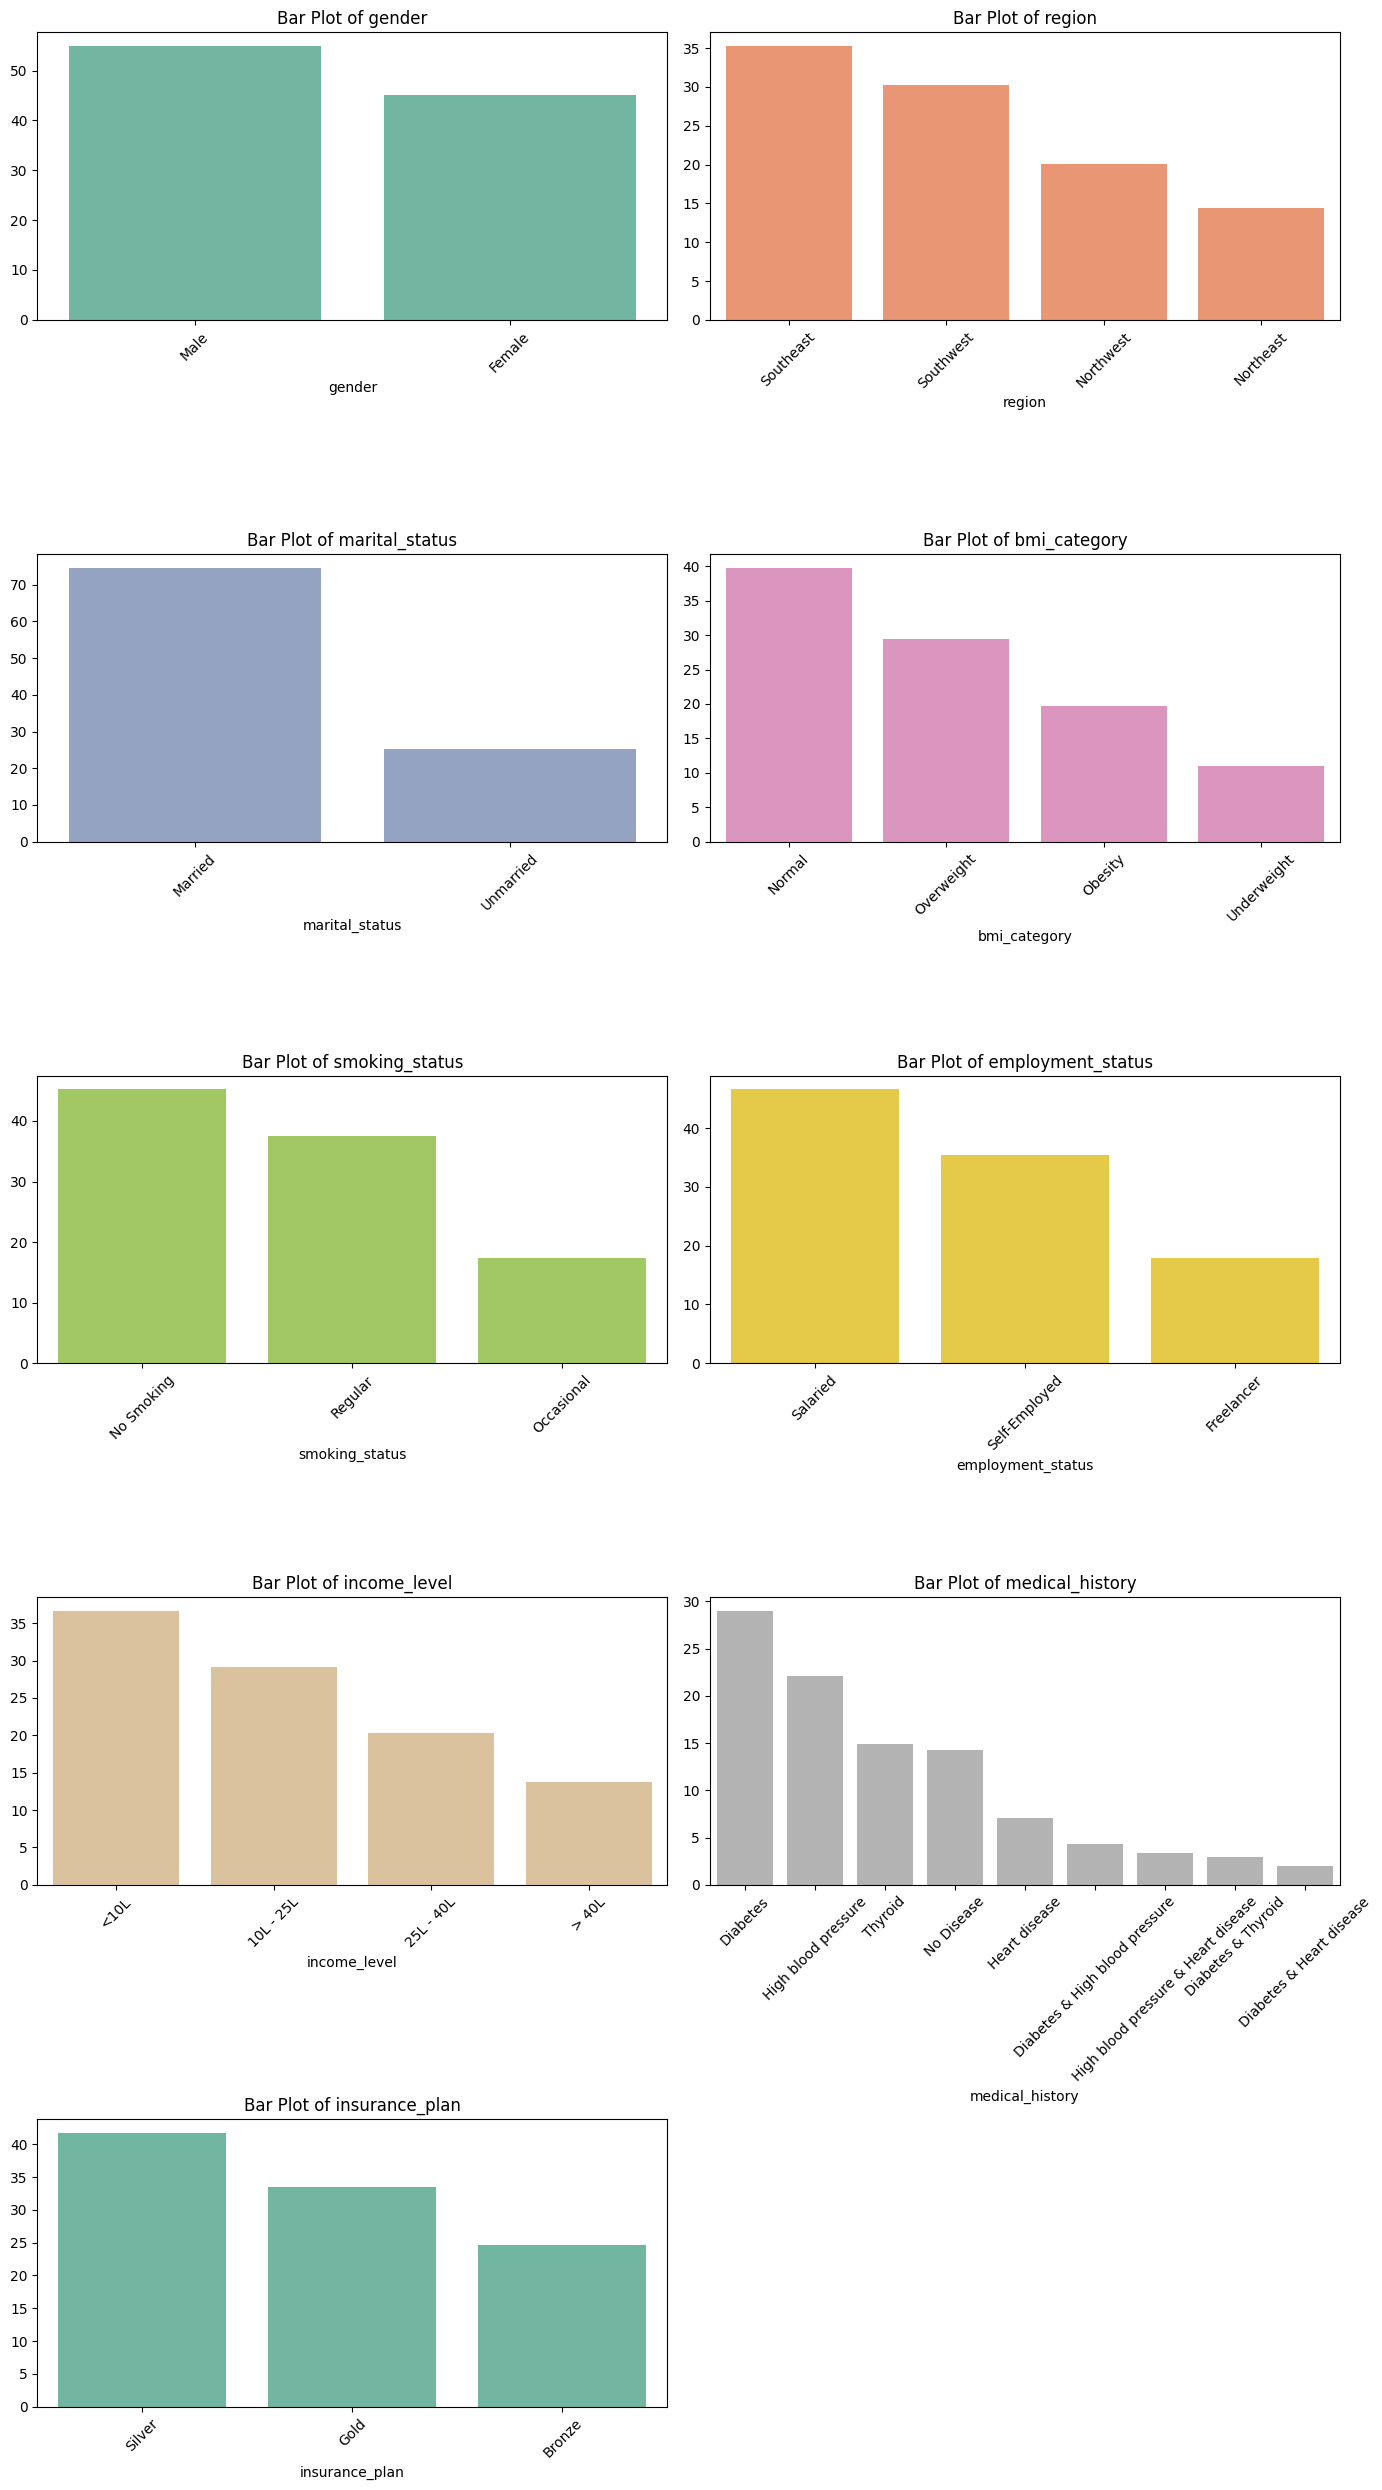

In [21]:

categorical_columns = df2.select_dtypes(include=['object','category','string']).columns

n_cols = 2
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# Generate colors
colors = sns.color_palette("Set2", len(categorical_columns))

for i, col in enumerate(categorical_columns):
    
    pct_count = df2[col].value_counts(normalize=True) * 100
    
    sns.barplot(
        x=pct_count.index,
        y=pct_count.values,
        ax=axes[i],
        color=colors[i]
    )
    
    axes[i].set_title(f'Bar Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide extra empty plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


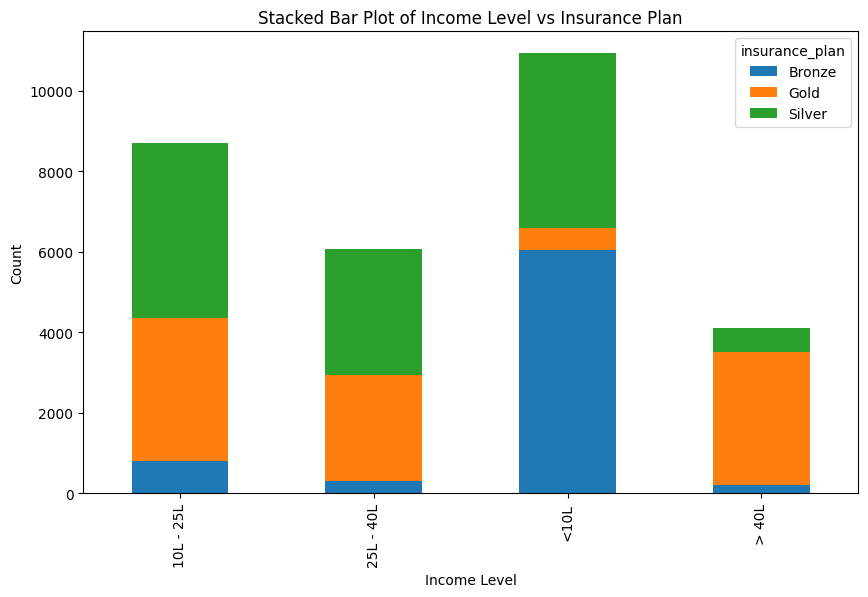

In [22]:
cross_tab = pd.crosstab(df2['income_level'],df2['insurance_plan'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Stacked Bar Plot of Income Level vs Insurance Plan')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

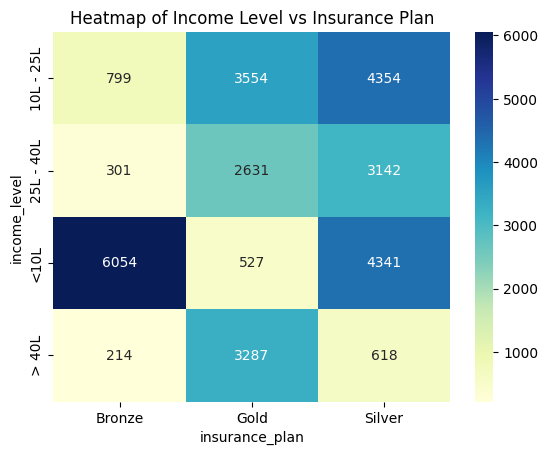

In [23]:
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Income Level vs Insurance Plan')
plt.show()

In [24]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

In [25]:
df2[['disease1','disease2']] = df2['medical_history'].str.split('&', expand=True).apply(lambda x: x.str.lower())
df2.fillna({'disease1': 'none', 'disease2': 'none'}, inplace=True)
for col in ['disease1', 'disease2']:
    df2[col] = df2[col].str.strip().str.lower()
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,high blood pressure,none
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,no disease,none
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,diabetes,none


In [26]:
df2['total_risk'] = 0
for disease in ['disease1', 'disease2']:
    df2['total_risk'] += df2[disease].map(risk_scores)
   
max_score = df2['total_risk'].max()
min_score = df2['total_risk'].min()
df2['normalized_risk_score'] = (df2['total_risk'] - min_score) / (max_score - min_score)
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,diabetes,none,6,0.428571


## Encode Text Columns

In [27]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [28]:
df2.income_level.unique()

<StringArray>
['<10L', '10L - 25L', '> 40L', '25L - 40L']
Length: 4, dtype: str

In [29]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [30]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,0,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,0,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,0,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,0,no disease,none,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,0,diabetes,none,...,0,0,0,1,0,0,1,0,0,1


In [31]:
df3.info()

<class 'pandas.DataFrame'>
Index: 29822 entries, 0 to 29903
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              29822 non-null  int64  
 1   number_of_dependants             29822 non-null  int64  
 2   income_level                     29822 non-null  int64  
 3   income_lakhs                     29822 non-null  int64  
 4   medical_history                  29822 non-null  str    
 5   insurance_plan                   29822 non-null  int64  
 6   annual_premium_amount            29822 non-null  int64  
 7   genetical_risk                   29822 non-null  int64  
 8   disease1                         29822 non-null  str    
 9   disease2                         29822 non-null  str    
 10  total_risk                       29822 non-null  int64  
 11  normalized_risk_score            29822 non-null  float64
 12  gender_Male                      2

In [32]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk'], axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


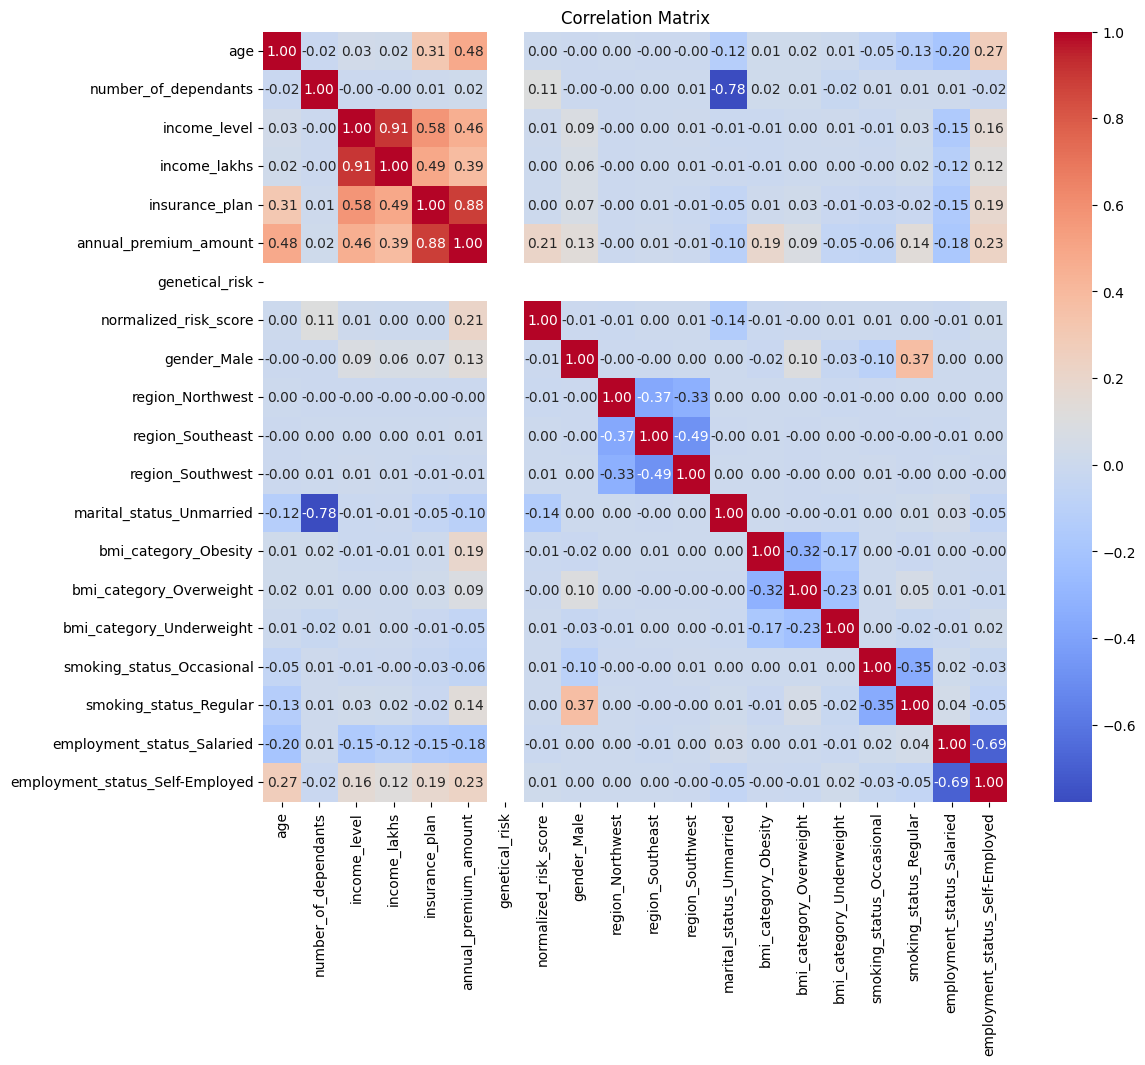

In [33]:
cm = df4.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

In [34]:
X = df4.drop('annual_premium_amount', axis=1)
y = df4['annual_premium_amount']
scaler = MinMaxScaler()
cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan','genetical_risk']
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.0,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.0,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.0,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.0,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.0,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.0,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data


In [36]:
calculate_vif(X.drop('income_level', axis=1))

c:\Users\pindu\anaconda3\envs\ml311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
0,age,3.863055
1,number_of_dependants,6.278147
2,income_lakhs,2.678102
3,insurance_plan,4.574625
4,genetical_risk,NaN
5,normalized_risk_score,3.808345
6,gender_Male,2.591439
7,region_Northwest,2.123277
8,region_Southeast,2.979899
9,region_Southwest,2.708641


In [37]:
X_reduced = X.drop('income_level', axis="columns")

## Model Training

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')
model = LinearRegression()
model.fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'Training R^2: {train_score:.4f}, Testing R^2: {test_score:.4f}')

Training set size: 20875 samples
Testing set size: 8947 samples
Training R^2: 0.9534, Testing R^2: 0.9538


In [39]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.4f}, MSE: {mse:.4f}')

RMSE: 1477.7836, MSE: 2183844.3603


In [40]:
model.coef_

array([ 7.01623933e+03, -1.31176470e+03, -7.08193369e+02,  1.48359882e+04,
        4.54747351e-13,  6.05362412e+03,  3.75582688e+01, -5.52508721e+01,
       -1.96225429e+01, -2.22896756e+01, -7.00320200e+02,  3.92681271e+03,
        1.97945605e+03,  6.12866236e+02,  8.37395101e+02,  2.80066184e+03,
       -4.54913671e+01,  2.43078421e+02])

In [41]:
model.intercept_

np.float64(5935.981289344443)

In [42]:
feature_importance = model.coef_
coeff_df = pd.DataFrame(feature_importance, index=X_reduced.columns, columns=['Coefficient'])
coeff_df = coeff_df.sort_values(by='Coefficient', ascending= True)

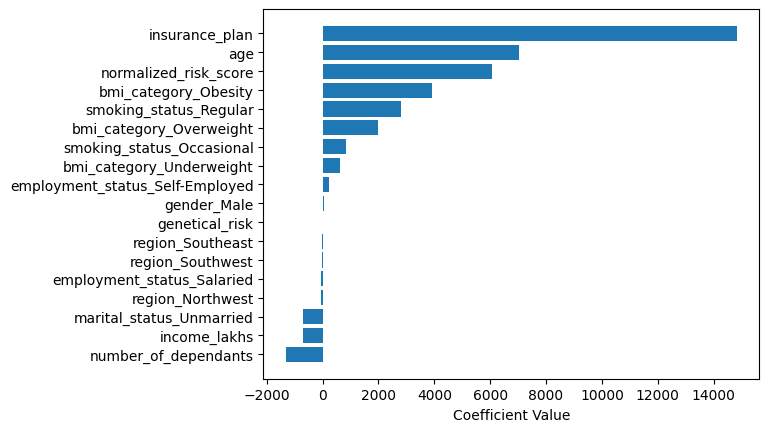

In [43]:
plt.barh(coeff_df.index, coeff_df['Coefficient'])
plt.xlabel('Coefficient Value') 
plt.show()

In [44]:
model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)
train_score = model_rg.score(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
print(f'Training R^2: {train_score:.4f}, Testing R^2: {test_score:.4f}')

Training R^2: 0.9534, Testing R^2: 0.9538


In [45]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
train_score = model_xgb.score(X_train, y_train)
test_score = model_xgb.score(X_test, y_test)
print(f'Training R^2: {train_score:.4f}, Testing R^2: {test_score:.4f}')

Training R^2: 0.9949, Testing R^2: 0.9948


In [46]:
y_pred = model_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.4f}, MSE: {mse:.4f}')

RMSE: 493.8094, MSE: 243847.7344


In [47]:
from sklearn.model_selection import RandomizedSearchCV


model_xgb = XGBRegressor()
model_params = {
    'n_estimators': [20, 40, 50],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}
random_search = RandomizedSearchCV(estimator=model_xgb, param_distributions=model_params, n_iter=10, cv=3, scoring = 'r2', random_state=42,n_jobs=-1)
random_search.fit(X_train, y_train)
print(f'Best Score: {random_search.best_score_}')
print(f'Best Parameters: {random_search.best_params_}')
best_model = random_search.best_estimator_

Best Score: 0.9970577955245972
Best Parameters: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}


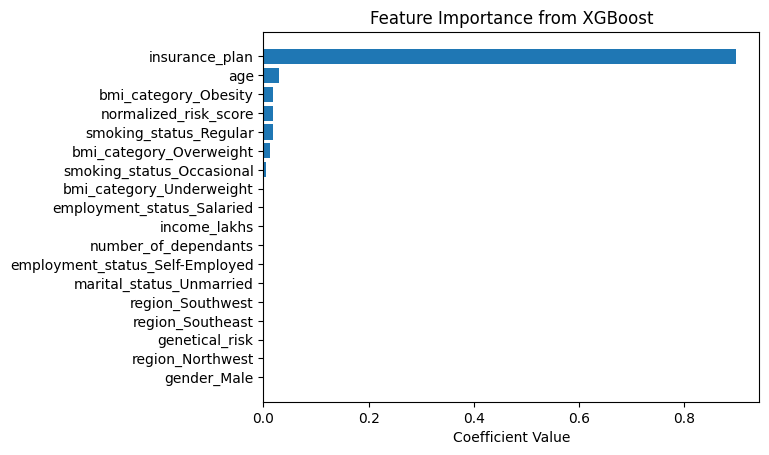

In [48]:
feature_importance = best_model.feature_importances_
coeff_df = pd.DataFrame(feature_importance, index=X_reduced.columns, columns=['Coefficient'])
coeff_df = coeff_df.sort_values(by='Coefficient', ascending= True)
plt.barh(coeff_df.index, coeff_df['Coefficient'])
plt.xlabel('Coefficient Value') 
plt.title('Feature Importance from XGBoost')
plt.show()

### Error Analysis

In [49]:
y_pred = best_model.predict(X_test)
diff = y_pred - y_test
diff_pct = (diff / y_test) * 100
error_df = pd.DataFrame({
    'Actual': y_test,   'Predicted': y_pred, 'Difference': diff, 'Difference_Pct': diff_pct })
error_df.head()


,Actual,Predicted,Difference,Difference_Pct
19713,26895,26691.470703,-203.529297,-0.756755
14750,22734,22650.751953,-83.248047,-0.366183
19932,21198,21581.894531,383.894531,1.810994
29643,9100,9425.934570,325.934570,3.581699
17076,26434,26691.470703,257.470703,0.974013


<Axes: xlabel='Difference_Pct', ylabel='Count'>

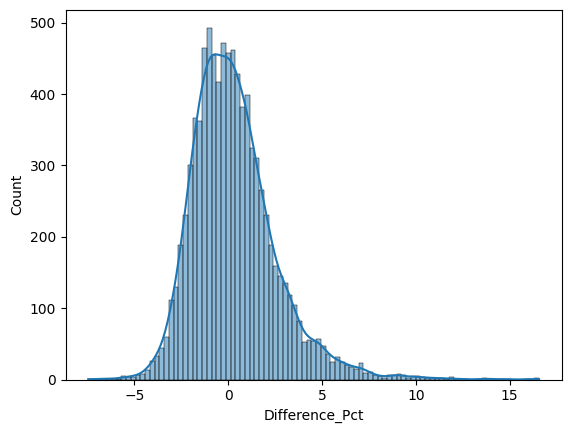

In [50]:
sns.histplot(error_df['Difference_Pct'], kde=True)

In [51]:
extreme_error_threshold = 10
df_extreme_errors = error_df[error_df['Difference_Pct'].abs() > extreme_error_threshold]
extreme_error_pct = df_extreme_errors.shape[0]/error_df.shape[0]*100
print(f'Percentage of predictions with more than {extreme_error_threshold}% error: {extreme_error_pct:.2f}%')

Percentage of predictions with more than 10% error: 0.32%


In [52]:
error_df[error_df['Difference_Pct'].abs() > 50].sort_values(by='Difference_Pct', ascending=False)

,Actual,Predicted,Difference,Difference_Pct


In [53]:
extreme_errors_data = X_test.loc[df_extreme_errors.index]

In [54]:
extreme_errors_data.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
14286,0.021739,0.6,0.050505,0.0,0.0,0.000000,1,1,0,0,1,0,0,0,0,0,1,0
27518,0.304348,0.6,0.080808,0.0,0.0,0.357143,1,1,0,0,0,0,0,0,0,0,0,1
9285,0.326087,0.6,0.010101,0.0,0.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
7547,0.347826,0.2,0.080808,0.0,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,1,0
21910,0.043478,0.6,0.020202,0.0,0.0,0.000000,1,0,1,0,0,0,0,0,0,0,0,0


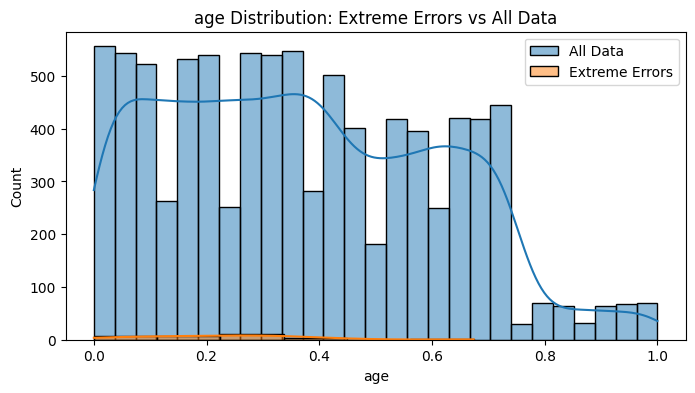

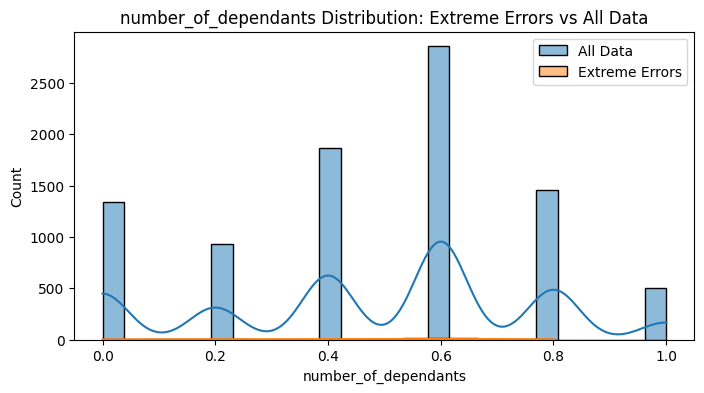

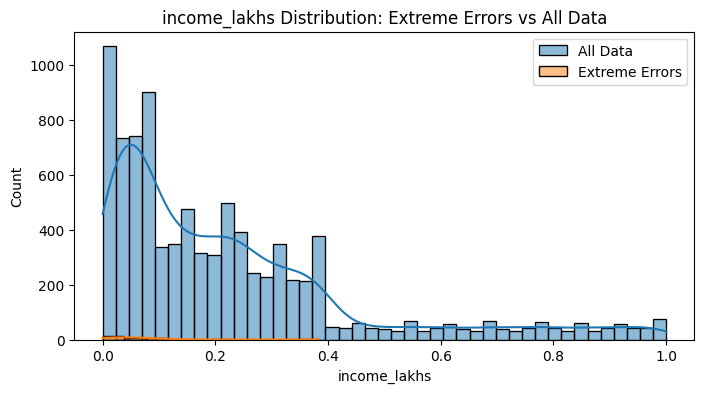

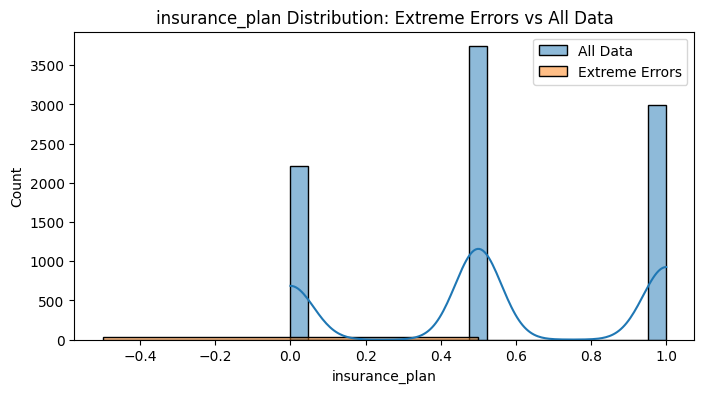

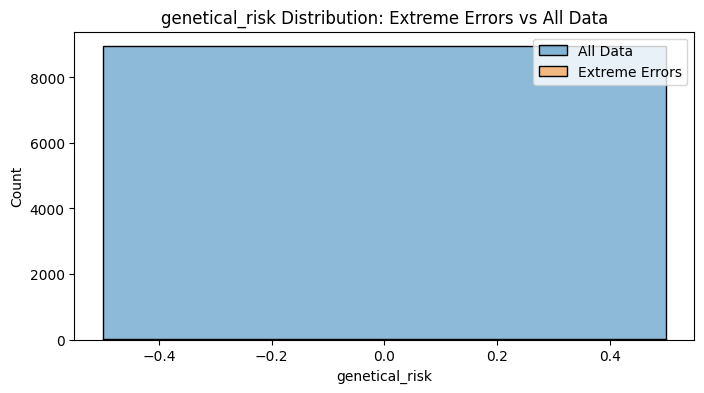

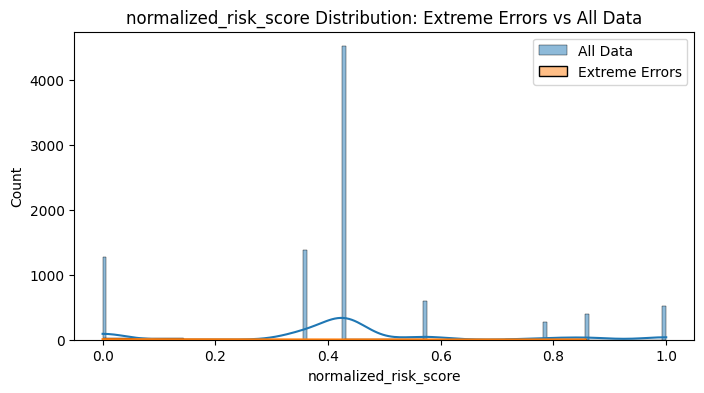

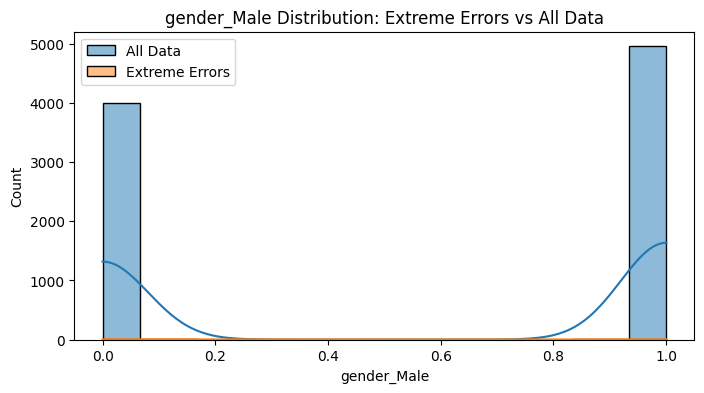

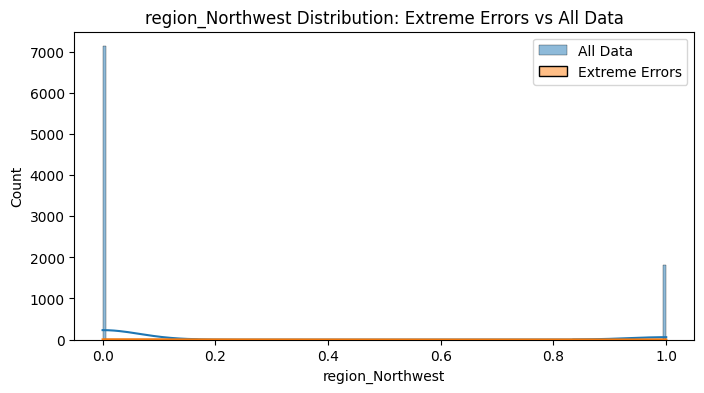

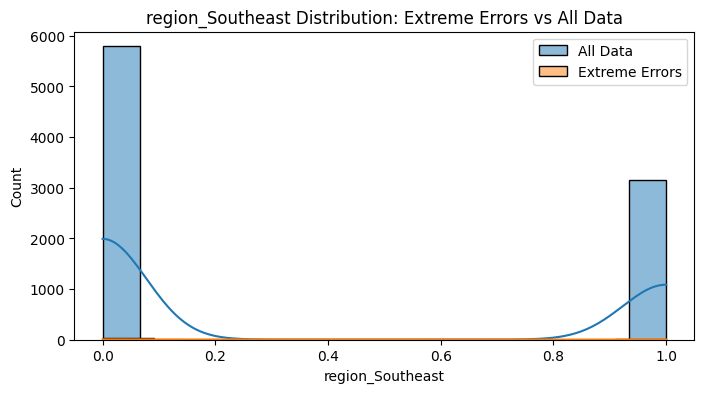

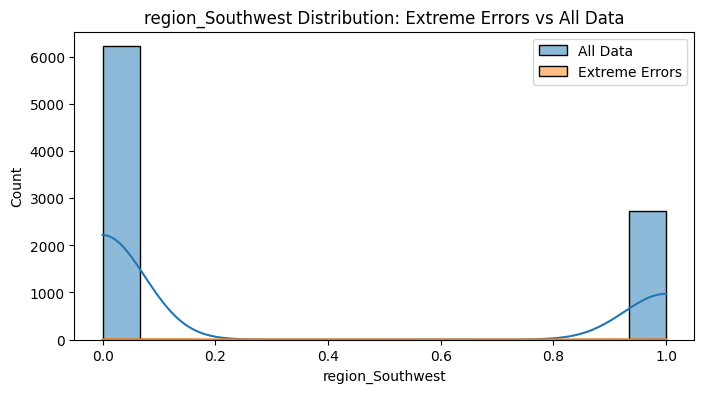

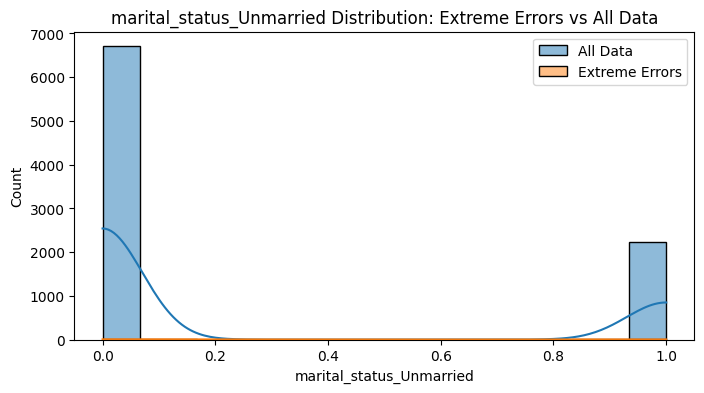

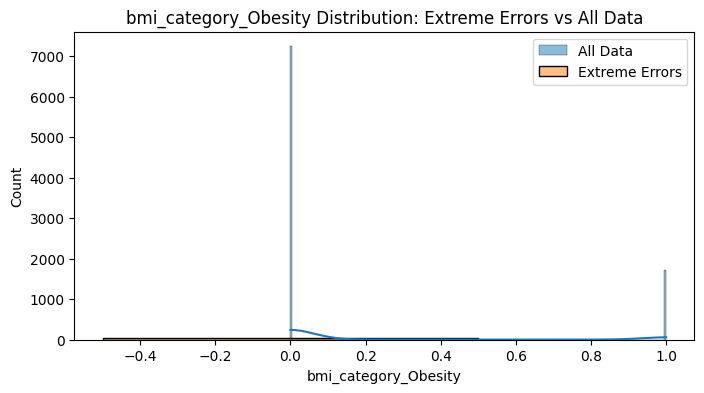

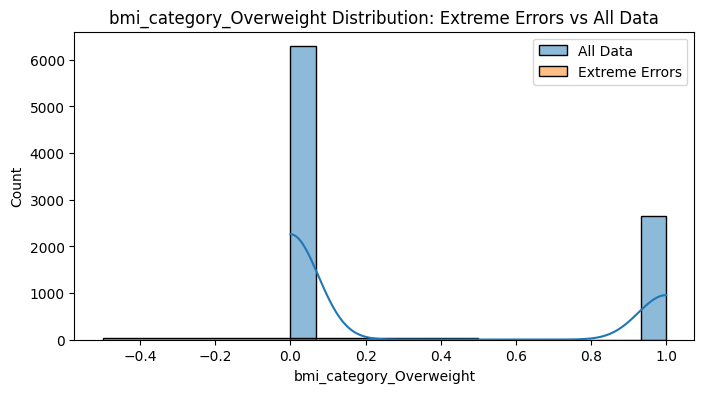

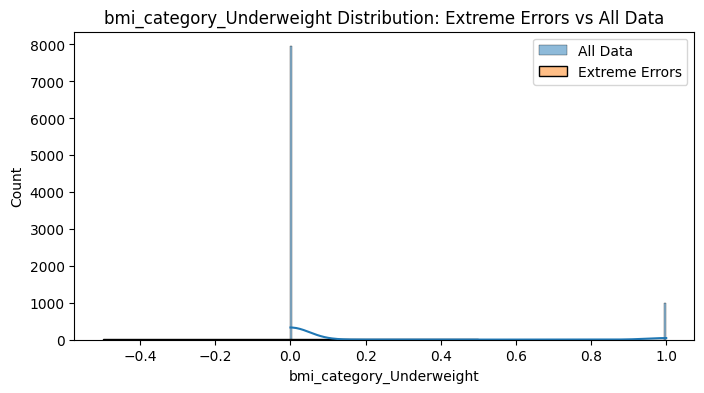

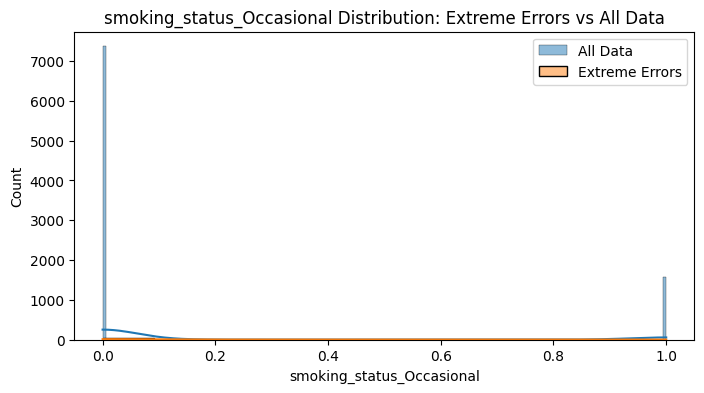

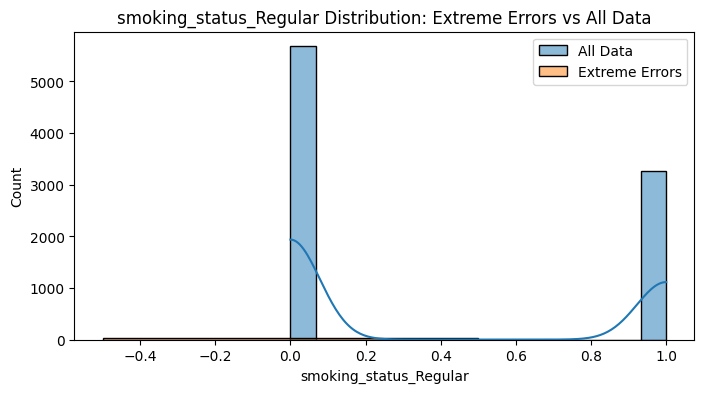

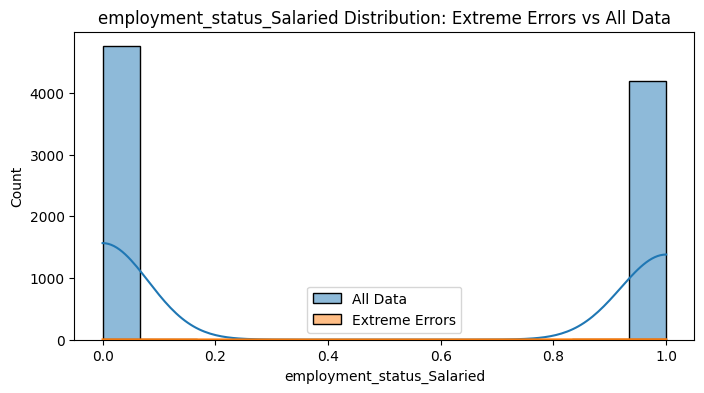

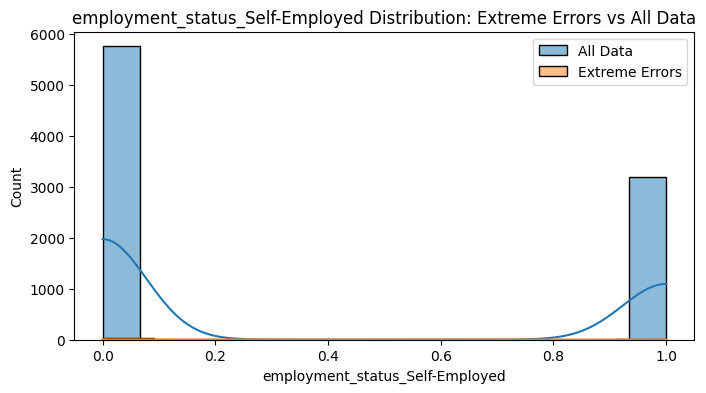

In [55]:
for feature in X_test.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_test[feature], label = "All Data", kde=True)
    sns.histplot(extreme_errors_data[feature],label = "Extreme Errors", kde=True)
    plt.legend()
    plt.title(f'{feature} Distribution: Extreme Errors vs All Data')
    plt.show()


In [56]:
extreme_errors_data['income_level'] = 0
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_data[cols_to_scale])

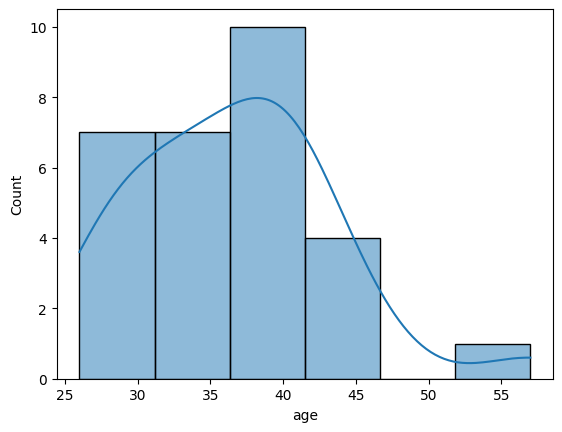

In [57]:
df_reversed.head()
sns.histplot(df_reversed['age'], kde=True)
plt.show()

In [58]:
df_reversed.age.quantile([0.97])

0.97    47.76
Name: age, dtype: float64

In [60]:
import joblib as jb
jb.dump(best_model, 'artifacts/model_rest.joblib')

['artifacts/model_rest.joblib']

In [61]:
scaler_rest = { 'scaler': scaler, 'cols_to_scale': cols_to_scale }
jb.dump(scaler_rest, 'artifacts/scaler_rest.joblib')

['artifacts/scaler_rest.joblib']